# Section 1 — Install & Import

In [1]:
import os, re, gc, warnings, random
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('dark_background')

import mne
mne.set_log_level('WARNING')
import librosa

from scipy.signal import butter, filtfilt, iirnotch, welch
from skimage.transform import resize

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW, NAdam
from torch.optim.lr_scheduler import (
    CosineAnnealingLR, OneCycleLR,
    ReduceLROnPlateau, CosineAnnealingWarmRestarts
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'MNE     : {mne.__version__}')

ModuleNotFoundError: No module named 'librosa'

# Section 2 — Global Configuration

In [10]:
# Paths 
DATA_ROOT = Path('/kaggle/input/datasets/amudhans07/chbmit-eeg-full-physionet-archive/chb_mit_part1/chb01/chb01-summary.txt')
SPEC_DIR  = Path('/kaggle/working/specs')
MODEL_DIR = Path('/kaggle/working/models')
SPEC_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CASES = ['chb01', 'chb02', 'chb03']

# Signal 
FS          = 256
N_CHANNELS  = 23
STANDARD_CHANNELS = [
    'FP1-F7','F7-T7','T7-P7','P7-O1',
    'FP1-F3','F3-C3','C3-P3','P3-O1',
    'FP2-F4','F4-C4','C4-P4','P4-O2',
    'FP2-F8','F8-T8','T8-P8','P8-O2',
    'FZ-CZ','CZ-PZ',
    'P7-T7','T7-FT9','FT9-FT10','FT10-T8','T8-P8'
]

# Frequency bands 
FREQ_BANDS = {
    'delta': (0.5,  4.0),
    'theta': (4.0,  8.0),
    'alpha': (8.0, 13.0),
    'beta' : (13.0, 30.0),
    'gamma': (30.0, 70.0),
}

# Filtering
BANDPASS_LOW  = 0.5
BANDPASS_HIGH = 70.0
NOTCH_FREQ    = 60.0   
FILTER_ORDER  = 4

# Windowing 
WINDOW_SEC    = 4
OVERLAP_SEC   = 2
WINDOW_SAMP   = WINDOW_SEC  * FS          # 1024 samples
STEP_SAMP     = (WINDOW_SEC - OVERLAP_SEC) * FS   # 512 samples
PRE_ICTAL_SEC = 5

# Spectrogram
N_MELS   = 64
NPERSEG  = 128
NOVERLAP = 64
FMIN     = 0.5
FMAX     = 70.0
IMG_SIZE = (64, 64)

# Memory guard 
MAX_INTERICTAL_PER_FILE = 300

# Training 
BATCH_SIZE   = 32
NUM_EPOCHS   = 50
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 10

print('Config loaded.')
print(f'  Spec cache : {SPEC_DIR}')
print(f'  Cases      : {CASES}')
print(f'  Max non-sz windows per file: {MAX_INTERICTAL_PER_FILE}')

Config loaded.
  Spec cache : /kaggle/working/specs
  Cases      : ['chb01', 'chb02', 'chb03']
  Max non-sz windows per file: 300


# Section 3 — Parse Summary Files

In [11]:
# Fix DATA_ROOT 
hits = glob.glob('/kaggle/input/**/chb01-summary.txt', recursive=True)

if hits:
    DATA_ROOT = Path(hits[0]).parent.parent   # auto-detect
    print(f'DATA_ROOT set to: {DATA_ROOT}')
else:
    raise FileNotFoundError(
        'Cannot find any chbNN-summary.txt files. '
    )
def parse_summary(summary_path):
    """chbNN-summary.txt → {edf_filename: [(start_sec, end_sec), ...]}"""
    seizures = defaultdict(list)
    current_file = None
    with open(summary_path, 'r', errors='replace') as f:
        lines = f.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith('File Name:'):
            current_file = line.split(':', 1)[1].strip()
        elif 'Seizure Start Time' in line and current_file:
            m = re.search(r'(\d+)', line)
            if not m:
                i += 1; continue
            start_sec = int(m.group(1))
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            if j < len(lines) and 'Seizure End Time' in lines[j]:
                me = re.search(r'(\d+)', lines[j])
                if me:
                    seizures[current_file].append((start_sec, int(me.group(1))))
                i = j
        i += 1
    return dict(seizures)


def build_annotation_table(cases, data_root):
    rows = []
    for case in cases:
        case_dir = data_root / case
        summaries = list(case_dir.glob('*-summary.txt'))
        if not summaries:
            print(f'  No summary for {case}'); continue
        sz = parse_summary(summaries[0])
        for fname, ivals in sz.items():
            for (s, e) in ivals:
                rows.append({'case': case, 'edf_file': str(case_dir / fname),
                             'sz_start': s, 'sz_end': e, 'sz_dur_sec': e - s})
    return pd.DataFrame(rows)

ann_df = build_annotation_table(CASES, DATA_ROOT)

# Guard against empty result
if ann_df.empty:
    raise RuntimeError(
        'ann_df is empty — no seizure annotations were loaded. '
        'Check DATA_ROOT and that summary files exist inside each case folder.'
    )

print(f'Seizure events found      : {len(ann_df)}')
print(f'EDF files with seizures   : {ann_df["edf_file"].nunique()}')
display(ann_df.head())


ann_df = build_annotation_table(CASES, DATA_ROOT)
print(f'Seizure events found : {len(ann_df)}')
print(f'EDF files with seizures: {ann_df["edf_file"].nunique()}')
display(ann_df.head())

DATA_ROOT set to: /kaggle/input/datasets/amudhans07/chbmit-eeg-full-physionet-archive/chb_mit_part1
Seizure events found      : 17
EDF files with seizures   : 17


,case,edf_file,sz_start,sz_end,sz_dur_sec
0,chb01,/kaggle/input/datasets/amudhans07/chbmit-eeg-f...,2996,3036,40
1,chb01,/kaggle/input/datasets/amudhans07/chbmit-eeg-f...,1467,1494,27
2,chb01,/kaggle/input/datasets/amudhans07/chbmit-eeg-f...,1732,1772,40
3,chb01,/kaggle/input/datasets/amudhans07/chbmit-eeg-f...,1015,1066,51
4,chb01,/kaggle/input/datasets/amudhans07/chbmit-eeg-f...,1720,1810,90


Seizure events found : 17
EDF files with seizures: 17


,case,edf_file,sz_start,sz_end,sz_dur_sec
0,chb01,/kaggle/input/datasets/amudhans07/chbmit-eeg-f...,2996,3036,40
1,chb01,/kaggle/input/datasets/amudhans07/chbmit-eeg-f...,1467,1494,27
2,chb01,/kaggle/input/datasets/amudhans07/chbmit-eeg-f...,1732,1772,40
3,chb01,/kaggle/input/datasets/amudhans07/chbmit-eeg-f...,1015,1066,51
4,chb01,/kaggle/input/datasets/amudhans07/chbmit-eeg-f...,1720,1810,90


# Section 4 — Preprocessing Utilities

In [12]:
def bandpass_filter(data, lowcut=BANDPASS_LOW, highcut=BANDPASS_HIGH, fs=FS, order=FILTER_ORDER):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)


def notch_filter(data, freq=NOTCH_FREQ, fs=FS, quality=30.0):
    nyq = 0.5 * fs
    for f in [freq, freq * 2]:
        if f < nyq:
            b, a = iirnotch(f / nyq, quality)
            data = filtfilt(b, a, data, axis=-1)
    return data


def is_artifact_window(window, threshold_uv=500.0):
    return bool(np.any(np.ptp(window, axis=-1) > threshold_uv))


def select_channels(raw):
    drop = [ch for ch in raw.ch_names if ch.strip() == '-']
    if drop: raw.drop_channels(drop)
    matched = [ch for ch in STANDARD_CHANNELS if ch in raw.ch_names]
    if len(matched) >= 4:
        raw.pick_channels(matched)
    else:
        raw.pick_types(eeg=True)
        if len(raw.ch_names) > N_CHANNELS:
            raw.pick_channels(raw.ch_names[:N_CHANNELS])
    return raw


def load_and_preprocess_edf(edf_path):
    raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)
    raw = select_channels(raw)
    raw.set_eeg_reference('average', projection=False, verbose=False)
    data, _ = raw[:]
    data    = data * 1e6           # V → µV
    fs      = int(raw.info['sfreq'])
    del raw; gc.collect()          # ← free MNE raw immediately

    data = notch_filter(data, freq=NOTCH_FREQ, fs=fs)
    data = bandpass_filter(data, fs=fs)

    # Robust per-channel normalisation
    median = np.median(data, axis=1, keepdims=True)
    iqr    = (np.percentile(data, 75, axis=1, keepdims=True)
            - np.percentile(data, 25, axis=1, keepdims=True))
    iqr[iqr == 0] = 1.0
    data = ((data - median) / iqr).astype(np.float32)
    return data, fs


print('Preprocessing utilities ready.')

Preprocessing utilities ready.


# Section 5 — Band Power & Spectrogram Utilities

In [13]:
def compute_band_power(window, fs=FS):
    nperseg = min(window.shape[-1], 128)
    freqs, psd = welch(window, fs=fs, nperseg=nperseg, axis=-1)
    total = np.trapz(psd, freqs, axis=-1)
    total[total == 0] = 1e-12
    return {
        band: np.trapz(psd[:, (freqs >= lo) & (freqs < hi)],
                       freqs[(freqs >= lo) & (freqs < hi)], axis=-1) / total
        for band, (lo, hi) in FREQ_BANDS.items()
    }


def mel_spec_1ch(sig, fs=FS):
    hop = NPERSEG - NOVERLAP
    mel = librosa.feature.melspectrogram(
        y=sig.astype(np.float32), sr=fs,
        n_fft=NPERSEG, hop_length=hop,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX
    )
    return librosa.power_to_db(mel, ref=np.max)   # (N_MELS, T)


def window_to_image(window, img_size=IMG_SIZE):
    """
    window: (n_ch, WINDOW_SAMP)  →  (1, H, W)  float32  normalised [0,1]
    Average Mel spectrogram across channels.
    """
    specs = np.stack([mel_spec_1ch(window[i]) for i in range(window.shape[0])])
    img   = specs.mean(axis=0)   # (N_MELS, T)
    img   = resize(img, img_size, anti_aliasing=True).astype(np.float32)
    mn, mx = img.min(), img.max()
    if mx > mn:
        img = (img - mn) / (mx - mn)
    return img[np.newaxis]       # (1, H, W)


print('Band power & spectrogram utilities ready.')

Band power & spectrogram utilities ready.


# Section 6 — Sanity-Check Visualization

Loading: /kaggle/input/datasets/amudhans07/chbmit-eeg-full-physionet-archive/chb_mit_part1/chb01/chb01_03.edf
  Shape=(21, 921600)  fs=256


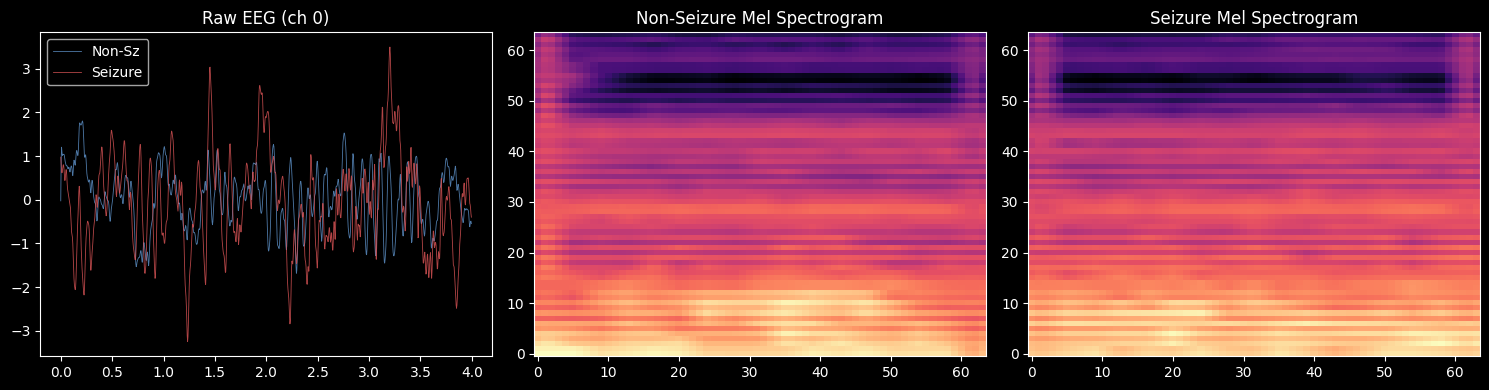

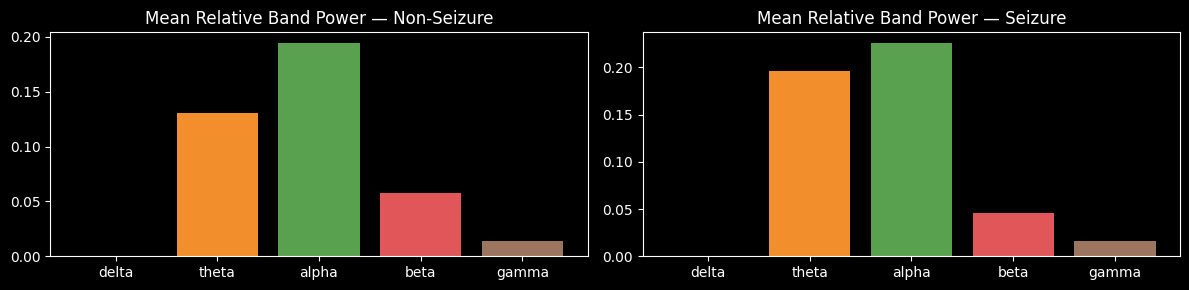

Sanity check done. RAM freed.


In [14]:
if len(ann_df) > 0:
    row = ann_df.iloc[0]
    print(f'Loading: {row.edf_file}')
    data, fs = load_and_preprocess_edf(row.edf_file)
    print(f'  Shape={data.shape}  fs={fs}')

    sz_s  = int(row.sz_start * fs)
    nsz_s = 0

    if sz_s + WINDOW_SAMP <= data.shape[1] and nsz_s + WINDOW_SAMP <= sz_s - PRE_ICTAL_SEC * fs:
        w_nz = data[:, nsz_s: nsz_s + WINDOW_SAMP]
        w_sz = data[:, sz_s:  sz_s  + WINDOW_SAMP]

        img_nz = window_to_image(w_nz)[0]
        img_sz = window_to_image(w_sz)[0]

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        t = np.arange(WINDOW_SAMP) / fs
        axes[0].plot(t, w_nz[0], lw=0.6, label='Non-Sz', color='#4e79a7')
        axes[0].plot(t, w_sz[0], lw=0.6, label='Seizure', color='#e15759', alpha=0.8)
        axes[0].set_title('Raw EEG (ch 0)'); axes[0].legend()
        axes[1].imshow(img_nz, aspect='auto', origin='lower', cmap='magma')
        axes[1].set_title('Non-Seizure Mel Spectrogram')
        axes[2].imshow(img_sz, aspect='auto', origin='lower', cmap='magma')
        axes[2].set_title('Seizure Mel Spectrogram')
        plt.tight_layout(); plt.show()

        # Band power
        fig2, ax2 = plt.subplots(1, 2, figsize=(12, 3))
        colors = ['#4e79a7','#f28e2b','#59a14f','#e15759','#9c755f']
        for ax, (w, lbl) in zip(ax2, [(w_nz,'Non-Seizure'),(w_sz,'Seizure')]):
            bp = compute_band_power(w, fs)
            means = {b: bp[b].mean() for b in FREQ_BANDS}
            ax.bar(means.keys(), means.values(), color=colors)
            ax.set_title(f'Mean Relative Band Power — {lbl}')
        plt.tight_layout(); plt.show()
    else:
        print('  Window bounds too short — skipping plot.')

    del data; gc.collect()
    print('Sanity check done. RAM freed.')

# Section 7 — Build Dataset: Stream EDF → NPY (Memory-Safe)

In [15]:
def label_array(n_samples, seizure_intervals, fs=FS, pre_ictal_sec=PRE_ICTAL_SEC):
    """0=interictal, 1=ictal, -1=pre-ictal exclusion zone."""
    lbl = np.zeros(n_samples, dtype=np.int8)
    for (s, e) in seizure_intervals:
        start_s, end_s = int(s * fs), int(e * fs)
        pre_s = max(0, start_s - pre_ictal_sec * fs)
        lbl[start_s:end_s] = 1
        lbl[pre_s:start_s] = -1
    return lbl


def process_one_edf(edf_path, seizure_intervals, case_tag, file_tag):
    """
    Process one EDF file: load → window → spectrogram → save .npy.
    Returns list of {'path': ..., 'label': ...}.
    RAM for this EDF is freed before return.
    """
    try:
        data, fs = load_and_preprocess_edf(edf_path)
    except Exception as ex:
        print(f'    SKIP {Path(edf_path).name}: {ex}')
        return []

    n_ch, n_samp = data.shape
    lbl          = label_array(n_samp, seizure_intervals, fs)
    records      = []
    ictal_saved  = 0
    inter_saved  = 0

    for start in range(0, n_samp - WINDOW_SAMP + 1, STEP_SAMP):
        win_lbl = lbl[start: start + WINDOW_SAMP]

        if np.any(win_lbl == -1):   # pre-ictal zone: skip
            continue

        label = int(np.mean(win_lbl) >= 0.5)

        # Cap non-seizure windows per file (memory + class balance)
        if label == 0 and inter_saved >= MAX_INTERICTAL_PER_FILE:
            continue

        window = data[:, start: start + WINDOW_SAMP]

        if is_artifact_window(window):   # drop noisy windows
            continue

        img      = window_to_image(window)   # (1, H, W) float32
        idx      = ictal_saved + inter_saved
        npy_path = SPEC_DIR / f'{case_tag}_{file_tag}_{idx:05d}.npy'
        np.save(str(npy_path), img)
        records.append({'path': str(npy_path), 'label': label})

        if label == 1: ictal_saved  += 1
        else:          inter_saved  += 1

    del data, lbl
    gc.collect()   # free EDF's RAM before loading the next one
    return records


# Run build loop 
MANIFEST_PATH = Path('/kaggle/working/manifest.csv')

if MANIFEST_PATH.exists():
    manifest = pd.read_csv(MANIFEST_PATH)
    print(f'Manifest already exists ({len(manifest)} windows). Delete it to rebuild.')
else:
    all_records = []
    print('Building dataset (streaming EDF → NPY) ...')

    for case in CASES:
        case_dir  = DATA_ROOT / case
        edf_files = sorted(case_dir.glob('*.edf'))
        case_ann  = ann_df[ann_df['case'] == case]
        print(f'\n{case}  ({len(edf_files)} EDFs, {len(case_ann)} seizure events)')

        for fi, edf_path in enumerate(edf_files):
            sz_rows  = case_ann[case_ann['edf_file'].str.endswith(edf_path.name)]
            sz_ivals = list(zip(sz_rows['sz_start'], sz_rows['sz_end']))

            recs = process_one_edf(
                edf_path, sz_ivals,
                case_tag=case, file_tag=f'f{fi:03d}'
            )
            all_records.extend(recs)
            n_sz  = sum(r['label'] == 1 for r in recs)
            n_nz  = len(recs) - n_sz
            print(f'  {edf_path.name}: {n_nz} interictal + {n_sz} seizure')

    manifest = pd.DataFrame(all_records)
    manifest.to_csv(MANIFEST_PATH, index=False)
    print(f'\nManifest saved → {MANIFEST_PATH}  ({len(manifest)} windows)')

print(f'\nClass counts:')
print(manifest['label'].value_counts().rename({0:'Non-Seizure', 1:'Seizure'}))
print(f'Seizure % : {100*manifest["label"].mean():.2f}%')

Building dataset (streaming EDF → NPY) ...

chb01  (42 EDFs, 7 seizure events)
  chb01_01.edf: 300 interictal + 0 seizure
  chb01_02.edf: 300 interictal + 0 seizure
  chb01_03.edf: 300 interictal + 20 seizure
  chb01_04.edf: 300 interictal + 13 seizure
  chb01_05.edf: 300 interictal + 0 seizure
  chb01_06.edf: 300 interictal + 0 seizure
  chb01_07.edf: 300 interictal + 0 seizure
  chb01_08.edf: 300 interictal + 0 seizure
  chb01_09.edf: 300 interictal + 0 seizure
  chb01_10.edf: 300 interictal + 0 seizure
  chb01_11.edf: 300 interictal + 0 seizure
  chb01_12.edf: 300 interictal + 0 seizure
  chb01_13.edf: 300 interictal + 0 seizure
  chb01_14.edf: 300 interictal + 0 seizure
  chb01_15.edf: 300 interictal + 20 seizure
  chb01_16.edf: 300 interictal + 25 seizure
  chb01_17.edf: 300 interictal + 0 seizure
  chb01_18.edf: 300 interictal + 45 seizure
  chb01_19.edf: 300 interictal + 0 seizure
  chb01_20.edf: 300 interictal + 0 seizure
  chb01_21.edf: 300 interictal + 46 seizure
  chb01_22.e

# Section 8 — Train / Val / Test Split

Train : 24711  seizure=0.014
Val   :  5295  seizure=0.014
Test  :  5296  seizure=0.014


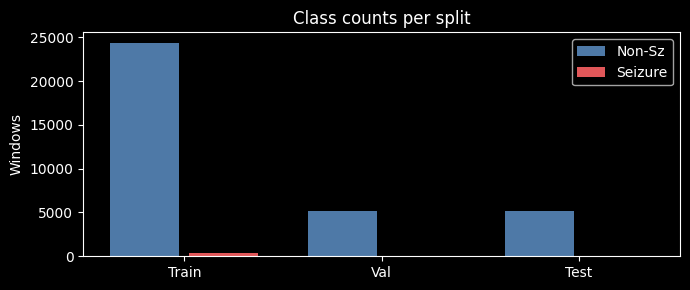

In [16]:
paths  = manifest['path'].values
labels = manifest['label'].values

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

print(f'Train : {len(y_tr):5d}  seizure={y_tr.mean():.3f}')
print(f'Val   : {len(y_val):5d}  seizure={y_val.mean():.3f}')
print(f'Test  : {len(y_te):5d}  seizure={y_te.mean():.3f}')

fig, ax = plt.subplots(figsize=(7, 3))
for i, (name, y) in enumerate({'Train': y_tr, 'Val': y_val, 'Test': y_te}.items()):
    ax.bar(i-0.2, (y==0).sum(), 0.35, color='#4e79a7', label='Non-Sz' if i==0 else '')
    ax.bar(i+0.2, (y==1).sum(), 0.35, color='#e15759', label='Seizure' if i==0 else '')
ax.set_xticks([0,1,2]); ax.set_xticklabels(['Train','Val','Test'])
ax.set_ylabel('Windows'); ax.set_title('Class counts per split'); ax.legend()
plt.tight_layout(); plt.show()

# Section 9 — Lazy Dataset & DataLoaders

In [33]:
class LazyEEGDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.paths   = paths
        self.labels  = torch.from_numpy(labels).long()
        self.augment = augment

    def __len__(self):  return len(self.labels)

    def __getitem__(self, idx):
        x = torch.from_numpy(np.load(self.paths[idx]))  # (1, H, W)
        if self.augment:
            x = self._spec_augment(x)
        return x, self.labels[idx]

    @staticmethod
    def _spec_augment(x, freq_p=8, time_p=8):
        x = x.clone()
        _, H, W = x.shape
        f  = random.randint(0, freq_p); f0 = random.randint(0, max(H-f, 0))
        x[:, f0:f0+f, :] = 0.0
        t  = random.randint(0, time_p); t0 = random.randint(0, max(W-t, 0))
        x[:, :, t0:t0+t] = 0.0
        return x


def make_sampler(y):
    counts  = np.bincount(y)
    weights = (1.0 / counts)[y]
    return WeightedRandomSampler(torch.DoubleTensor(weights), len(y), replacement=True)


train_ds = LazyEEGDataset(X_tr,  y_tr,  augment=True)
val_ds   = LazyEEGDataset(X_val, y_val, augment=False)
test_ds  = LazyEEGDataset(X_te,  y_te,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=make_sampler(y_tr),
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))
print(f'Batch shape  : X={xb.shape}  y={yb.shape}')
print(f'Loaders      : train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}')

Batch shape  : X=torch.Size([32, 1, 64, 64])  y=torch.Size([32])
Loaders      : train=773  val=166  test=166
